# ESPM Course 2025
## Sixth Notebook
Linear diffusion equation in two dimension using an implict finite difference scheme (ADI)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import numba

In [3]:
@numba.njit
def tridag(a, b, c, r):
    """
    Function to solve a tri-diagonal system of equations
    a is lower diagonal, b is diagonal, c is upper diagonal, r is rhigh hand side
    tridag returns an array of size n containing the solution to the system of equations
    """

    n = len(r)
    res = np.empty(n)
    gam = np.empty(n)

    if b[0] == 0:
        raise RuntimeError("diagonal contains nil element in tridag")

    bet = b[0]
    res[0] = r[0] / bet
    for j in range(1, n):  # in Fortran the range is 2,n
        gam[j] = c[j - 1] / bet
        bet = b[j] - a[j] * gam[j]
        if bet == 0:
            raise RuntimeError("diagonal contains nil element in tridag")
        res[j] = (r[j] - a[j] * res[j - 1]) / bet

    for j in range(n - 2, -1, -1):  # in Fortran the range is n-1,1,-1
        res[j] = res[j] - gam[j + 1] * res[j + 1]

    return res

In [4]:
xl = 1000
yl = 2000
nx = 101
ny = 201
x,y = np.meshgrid(np.linspace(0, xl, nx), np.linspace(0, yl, ny))
dx = xl/(nx -1)
dy = yl/(ny -1)
Kd = 1e-2
xn = 2
yn = 3
taux = xl**2/Kd/4/np.pi**2/xn**2
tauy = yl**2/Kd/4/np.pi**2/yn**2
tau = np.amax([taux, tauy])
nstep = 100
dt = tau/nstep

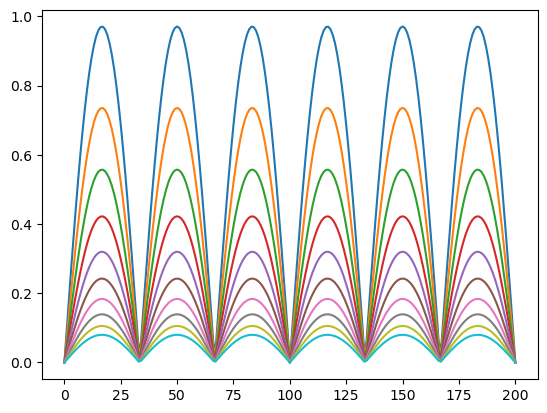

In [7]:
h = np.sin(x/xl*xn*2*np.pi)*np.sin(y/yl*yn*2*np.pi)

courantx = Kd*dt/2/(dx**2)
diagx = np.ones(nx)*(1 + 2*courantx)
supx = np.ones(nx)*(-courantx)
subx = np.ones(nx)*(-courantx)
diagx[0] = 1
diagx[-1] = 1
supx[0] = 0
subx[-1] = 0

couranty = Kd*dt/2/(dy**2)
diagy = np.ones(ny)*(1 + 2*couranty)
supy = np.ones(ny)*(-couranty)
suby = np.ones(ny)*(-couranty)
diagy[0] = 1
diagy[-1] = 1
supy[0] = 0
suby[-1] = 0

for step in range(nstep):
    for j in range(1,ny-1):
        hp = h[j,:].copy()
        hp[1:-1] = hp[1:-1] + couranty*(hp[:-2] - 2*hp[1:-1] + hp[2:])
        h[j,:] = tridag(subx, diagx, supx, hp)
    for i in range(1,nx-1):
        hp = h[:,i].copy()
        hp[1:-1] = hp[1:-1] + courantx*(hp[:-2] - 2*hp[1:-1] + hp[2:])
        h[:,i] = tridag(suby, diagy, supy, hp)
    if step%(nstep/10)==0:
        plt.plot(h.max(1))
    